# Taller ingeniería de datos

El problema que se desea resolver haciendo un modelo predictivo es el siguiente:

*En la industria de telecomunicaciones, la **retención de clientes** es uno de los mayores desafíos para las empresas, ya que la pérdida de clientes (churn) afecta directamente los ingresos y la sostenibilidad del negocio. En este contexto, la empresa que proporciona servicios de telecomunicaciones a través del dataset tiene como objetivo reducir la **tasa de cancelación de sus servicios**. En particular, la variable **Churn Label** identifica a aquellos clientes que han decidido abandonar el servicio. Para abordar este problema, es crucial predecir con antelación qué clientes podrían cancelar su suscripción, para implementar estrategias de retención específicas. Este análisis predictivo no solo ayudaría a identificar a los clientes en riesgo de churn, sino que también podría revelar factores determinantes como la **razón de cancelación**, **tipos de contrato**, **método de pago**, **tasa de uso** y otras variables que influyen en la decisión de los clientes. Por lo tanto, realizar un análisis predictivo basado en estas variables permitirá a la empresa tomar medidas proactivas para mejorar su **estrategia de fidelización** y, en última instancia, reducir el churn y aumentar la **rentabilidad** a largo plazo.*

El equipo de análisis cuenta con un dataset cuyo diccionario de datos se puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

## Carga e identificación de problemas de los datos

Abra el archivo de datos en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargue en `Pandas` el archivo dado, que contiene un dataset cuya información puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

Indique cuántas variables y registros tiene el dataset, y asegúrese que el tipo de dato de cada variable sea el esperado.

Reporte las estadísticas descriptivas de las variables numéricas y categóricas.

Identifique si el dataframe tiene datos duplicados.

Identifique si hay variables con datos nulos.

Reporte los hallazgos en un celda de texto.

In [39]:
from pathlib import Path
import pandas as pd

#aqui le decimos a python en que carpeta estan los datos
DATA_DIR = Path().resolve().parent / "data" / "raw"
data_file = "Telco_customer_churn.csv"
data_path = DATA_DIR / data_file
df = pd.read_csv(data_path,na_values=[' ']) 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [40]:
#Estadistica de las numericas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Zip Code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
Latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Tenure Months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
Monthly Charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
Total Charges,7032.0,2283.300441,2266.771362,18.800000,401.450000,1397.475000,3794.737500,8684.800000
Churn Value,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
Churn Score,7043.0,58.699418,21.525131,5.000000,40.000000,61.000000,75.000000,100.000000
CLTV,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000


In [41]:
#Estadistica de las categoricas
df.describe(include="object").T

,count,unique,top,freq
CustomerID,7043,7043,3668-QPYBK,1
Country,7043,1,United States,7043
State,7043,1,California,7043
City,7043,1129,Los Angeles,305
Lat Long,7043,1652,"34.159534, -116.425984",5
Gender,7043,2,Male,3555
Senior Citizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,5416
Phone Service,7043,2,Yes,6361


In [42]:
df.duplicated().sum()

np.int64(0)

In [43]:
df.isnull().sum().sort_values(ascending=False).head(5)

Churn Reason     5174
Total Charges      11
CustomerID          0
Count               0
Country             0
dtype: int64

RTA: 

TODAS LAS VARIBLES SE LEYERON EN EL FORMATO CORRECTO 

NO SE ENCONTRARON VALORES DUBLICADOS 

COUNTRY Y STATE SOLO TIENE UN VALOR ES DECIR, ES CONSTANTE 

VARIABLES CON DATOS NULOS: Churn Reason, Total Charges

Descarte las variables que considere irrelevantes para su modelo (p.e. claves priamrias, variables con valores únicos, variables redundantes, entre otros).

Gestione los datos duplicados y los datos nulos.

In [44]:
df = df.set_index('CustomerID')

In [ ]:
#eliminar 
df = df.drop(columns=['Count', 'Country', 'State', 'Lat Long'])

In [47]:
df =  df.drop_duplicates()#borra dublicado

In [49]:
df = df.drop(columns=['Churn Reason'])#Elimina de forma permanente la columna 'Churn Reason' del DataFrame.
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 3668-QPYBK to 3186-AJIEK
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   object 
 1   Zip Code           7043 non-null   int64  
 2   Latitude           7043 non-null   float64
 3   Longitude          7043 non-null   float64
 4   Gender             7043 non-null   object 
 5   Senior Citizen     7043 non-null   object 
 6   Partner            7043 non-null   object 
 7   Dependents         7043 non-null   object 
 8   Tenure Months      7043 non-null   int64  
 9   Phone Service      7043 non-null   object 
 10  Multiple Lines     7043 non-null   object 
 11  Internet Service   7043 non-null   object 
 12  Online Security    7043 non-null   object 
 13  Online Backup      7043 non-null   object 
 14  Device Protection  7043 non-null   object 
 15  Tech Support       7043 non-null   object 
 16  Streaming TV  

In [50]:
df = df.dropna(subset=['Total Charges'])

In [51]:
df.isnull().sum().sort_values(ascending=False).head(5)

City         0
Zip Code     0
Latitude     0
Longitude    0
Gender       0
dtype: int64

## Análisis de variables categóricas

Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables que no deberían incluirse en la matriz de características.

Reporte los resultados del análisis en una celda de texto.

In [74]:
#Mostrar todos los posibles resultados de una varible tipo object
var_categoricas = df.select_dtypes(include="object").columns 
for var in var_categoricas: 
    print(f'{var} : {df[var].unique()}')

Gender : ['Male' 'Female']
Senior Citizen : ['No' 'Yes']
Partner : ['No' 'Yes']
Dependents : ['No' 'Yes']
Phone Service : ['Yes' 'No']
Multiple Lines : ['No' 'Yes' 'No phone service']
Internet Service : ['DSL' 'Fiber optic' 'No']
Online Security : ['Yes' 'No' 'No internet service']
Online Backup : ['Yes' 'No' 'No internet service']
Device Protection : ['No' 'Yes' 'No internet service']
Tech Support : ['No' 'Yes' 'No internet service']
Streaming TV : ['No' 'Yes' 'No internet service']
Streaming Movies : ['No' 'Yes' 'No internet service']
Contract : ['Month-to-month' 'Two year' 'One year']
Paperless Billing : ['Yes' 'No']
Payment Method : ['Mailed check' 'Electronic check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn Label : ['Yes' 'No']


De este analisis se concluye que la variable categorica city es de alta cardinalidad 

## EDA 

In [ ]:
df = df.drop(columns=['City'])


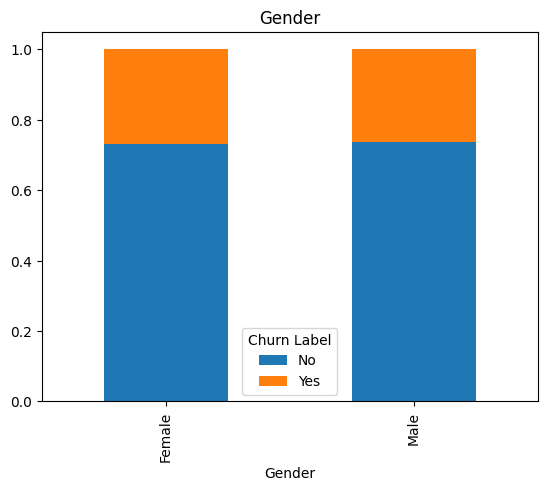

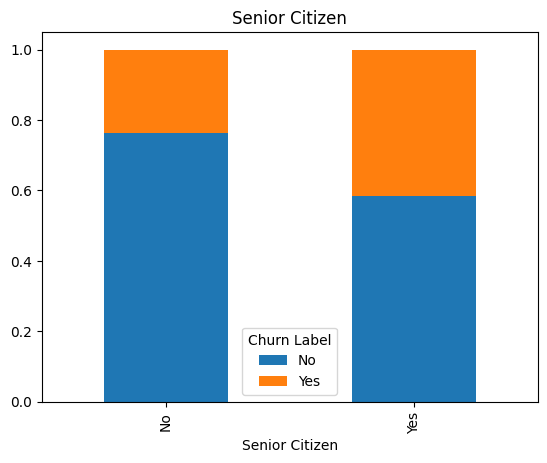

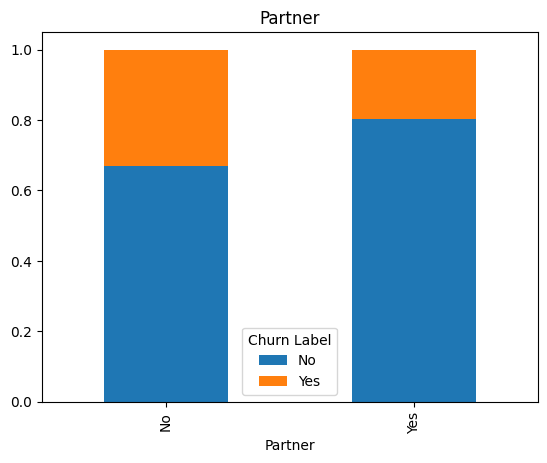

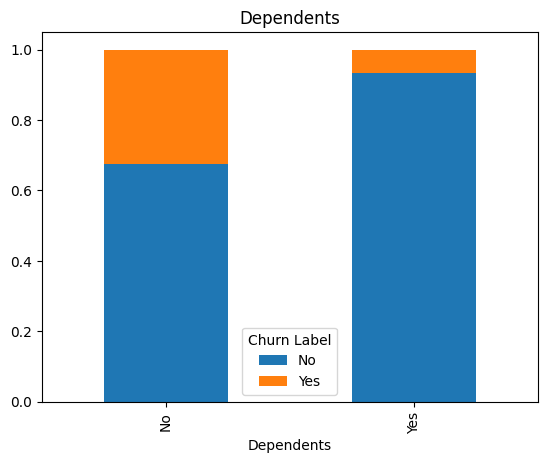

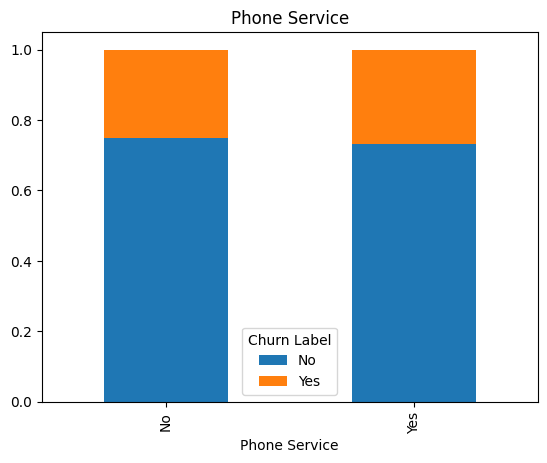

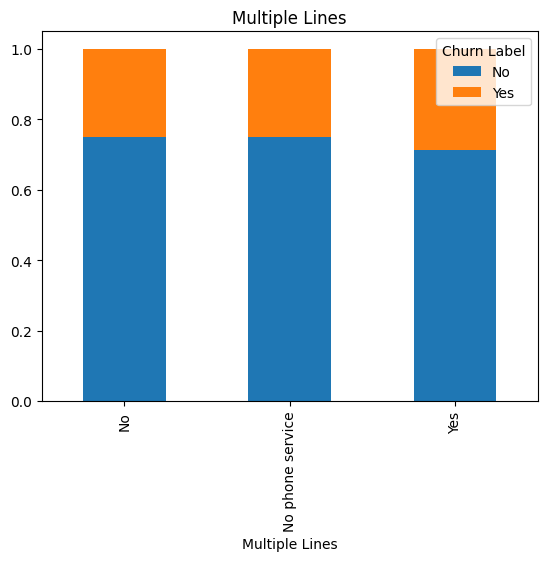

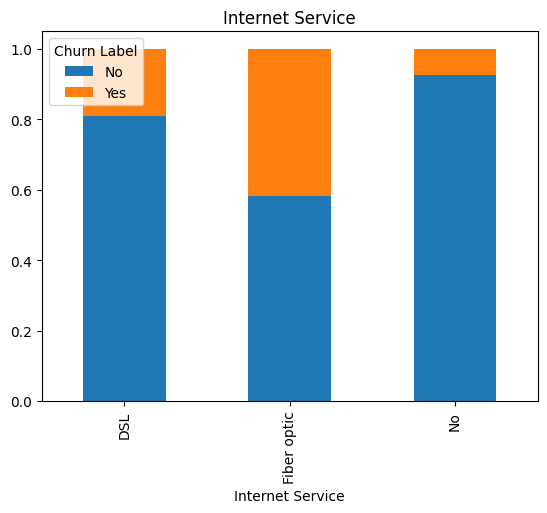

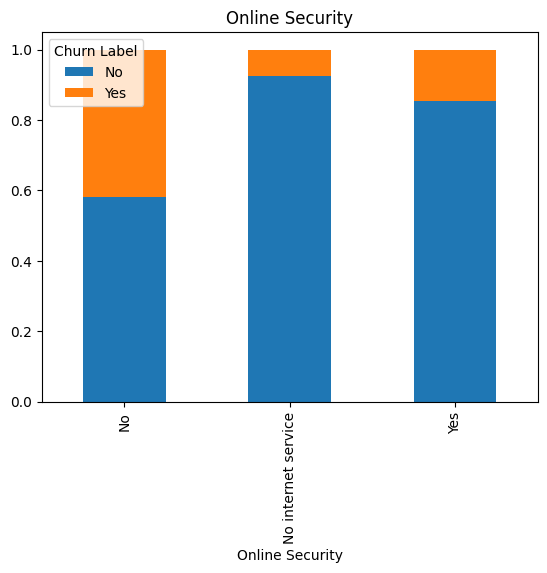

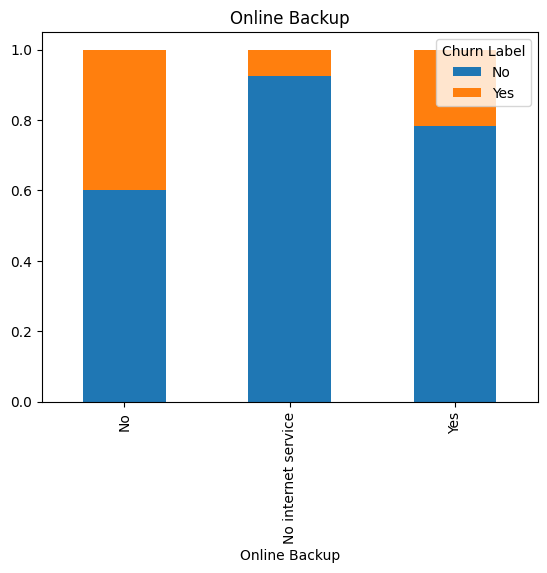

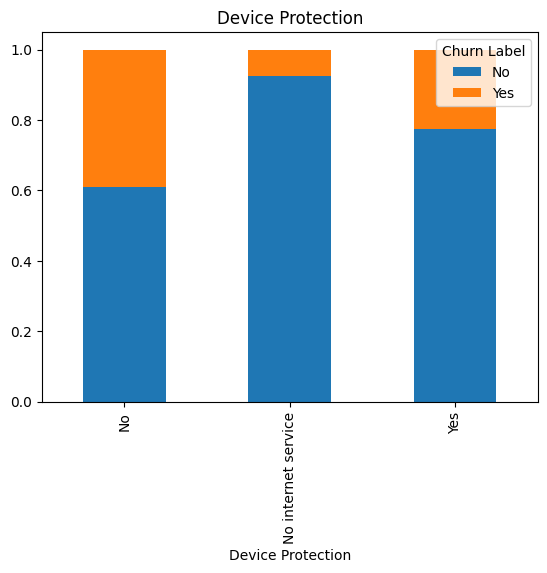

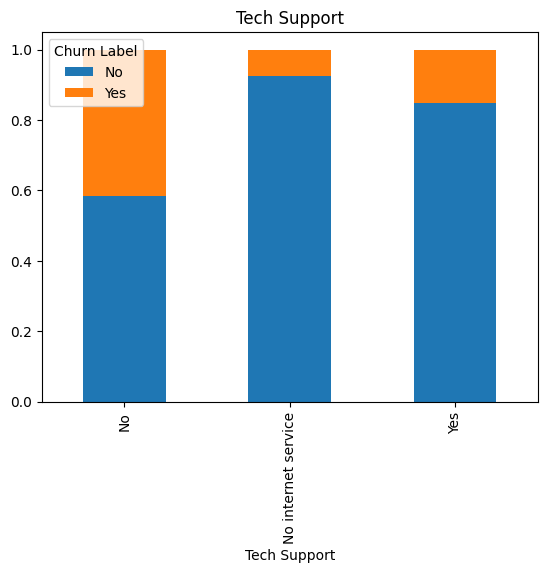

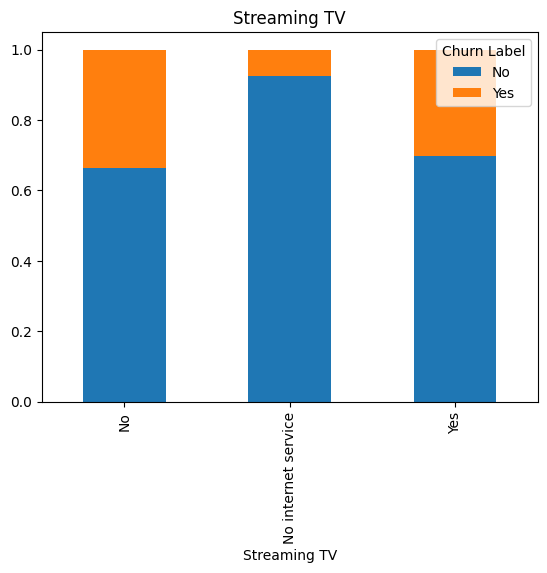

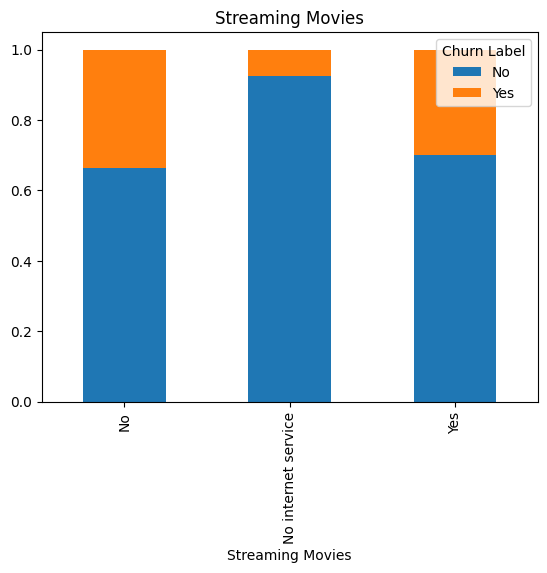

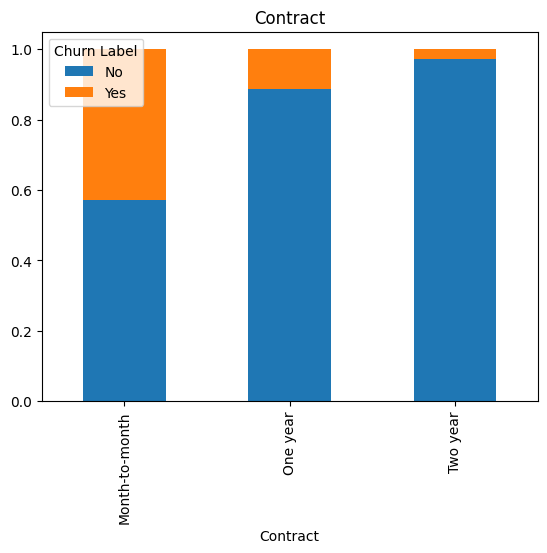

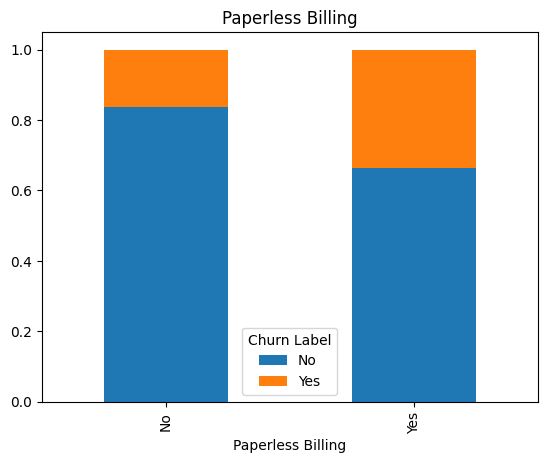

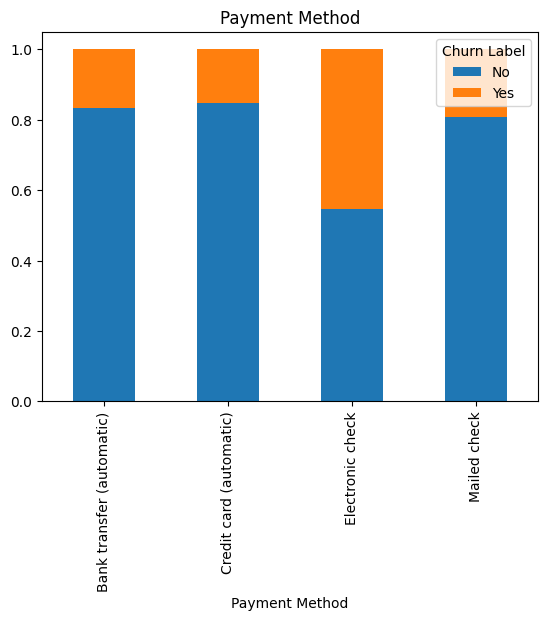

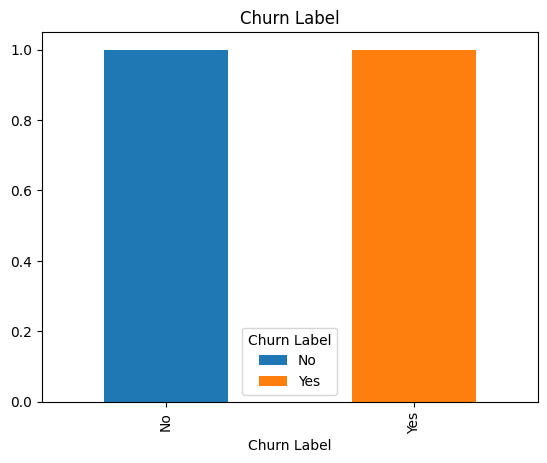

In [75]:
import matplotlib.pyplot as plt

#analsis bivairado entre variables categoricas y variable objetivo: churn label
for var in var_categoricas:
    tabla = pd.crosstab(df[var], df['Churn Label'], normalize='index')
    tabla.plot(kind='bar', stacked=True)
    plt.title(var)
    plt.show()

## Análisis de variables cuantitativas

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.
- Variables que no deberían incluirse en la matriz de características.

Reporte los resultados del análisis en una celda de texto.

## Entrenamiento del modelo

Entrene un modelo de árbol de decisión que prediga la variable **Churn Value**.

Procese las variables de acuerdo con los análisis de variables cuantitativas y categóricas hechos previamente. Este procesamiento debe empaquetarse usando `ColumnTransformer`, para que los datos de entrenamiento y prueba sean procesados por separado.

Reporte los `scores` de entrenamiento y prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del preprocesamiento.